In [ ]:
!pip install numpy==1.26.4
!pip install scipy==1.12.0
!pip install scikit-learn==1.3.2
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install psutil
!pip install pandas matplotlib seaborn
!pip install datasets --upgrade
!pip install qwen-vl-utils
!pip -q install trl
!pip install transformers accelerate
!pip install peft
!pip install bitsandbytes

In [ ]:
import os
import gc
import time
import torch
import torchvision
import psutil
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:256"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [ ]:
# =================================================================================
# DATA PREPARATION & PATIENT-LEVEL STRATIFIED SPLIT
# =================================================================================

import pandas as pd
import numpy as np
df = pd.read_csv("training_dataset_final_augmented_shrunk.csv")

patient_labels = df.groupby("patient_id")["label"].apply(
    lambda x: "fracture" if "fracture" in x.values else "normal"
)

def stratified_patient_split(patient_labels, train_ratio=0.9, val_ratio=0.05, seed=42):
    np.random.seed(seed) 
    patients_by_label = {
        label: list(patients.index)
        for label, patients in patient_labels.groupby(patient_labels)
    }
    splits = {"train": [], "val": [], "test": []}
    for label, patients in patients_by_label.items():
        np.random.shuffle(patients)
        n = len(patients)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)

        splits["train"].extend(patients[:n_train])
        splits["val"].extend(patients[n_train:n_train + n_val])
        splits["test"].extend(patients[n_train + n_val:])

    return splits
splits = stratified_patient_split(patient_labels, train_ratio=0.9, val_ratio=0.05)

train_df = df[df["patient_id"].isin(splits["train"])].reset_index(drop=True)
val_df   = df[df["patient_id"].isin(splits["val"])].reset_index(drop=True)
test_df  = df[df["patient_id"].isin(splits["test"])].reset_index(drop=True)

label_map = {"normal": 0, "fracture": 1}
for split_df in [train_df, val_df, test_df]:
    split_df["label_id"] = split_df["label"].map(label_map)


train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)


In [ ]:
train_df.head()

,filestem,patient_id,image_path,fracture_visible,ao_classification,label,fracture_bboxes,label_id
0,0001_1297860435_01_WRI-L2_M014,1,Augmented_Images/0001_1297860435_01_WRI-L2_M01...,1.0,23r-M/2.1,fracture,"[[202.0, 438.0, 334.0, 498.0]]",1
1,0001_1297860435_01_WRI-L2_M014_aug0,1,Augmented_Images/0001_1297860435_01_WRI-L2_M01...,1.0,23r-M/2.1,fracture,"[[201.90286378071227, 433.1486438873, 325.9911...",1
2,0005_0073601967_01_WRI-R2_F014,5,Augmented_Images/0005_0073601967_01_WRI-R2_F01...,1.0,23r-M/2.1,fracture,"[[313.5, 515.25, 424.5, 588.75]]",1
3,0005_0073601967_01_WRI-R2_F014_aug0,5,Augmented_Images/0005_0073601967_01_WRI-R2_F01...,1.0,23r-M/2.1,fracture,"[[330.29777971866383, 518.1057450738326, 443.6...",1
4,0006_0290481819_01_WRI-R2_M011,6,Augmented_Images/0006_0290481819_01_WRI-R2_M01...,1.0,23r-M/2.1,fracture,"[[298.5, 622.375, 379.5, 684.625]]",1


Dataframes are already in memory.

--- Numerical Summary of Splits ---
Train distribution: {'fracture': 19964, 'normal': 15270}
Validation distribution: {'fracture': 1084, 'normal': 807}
Test distribution: {'fracture': 1114, 'normal': 813}

--- Visual Summary of Splits ---


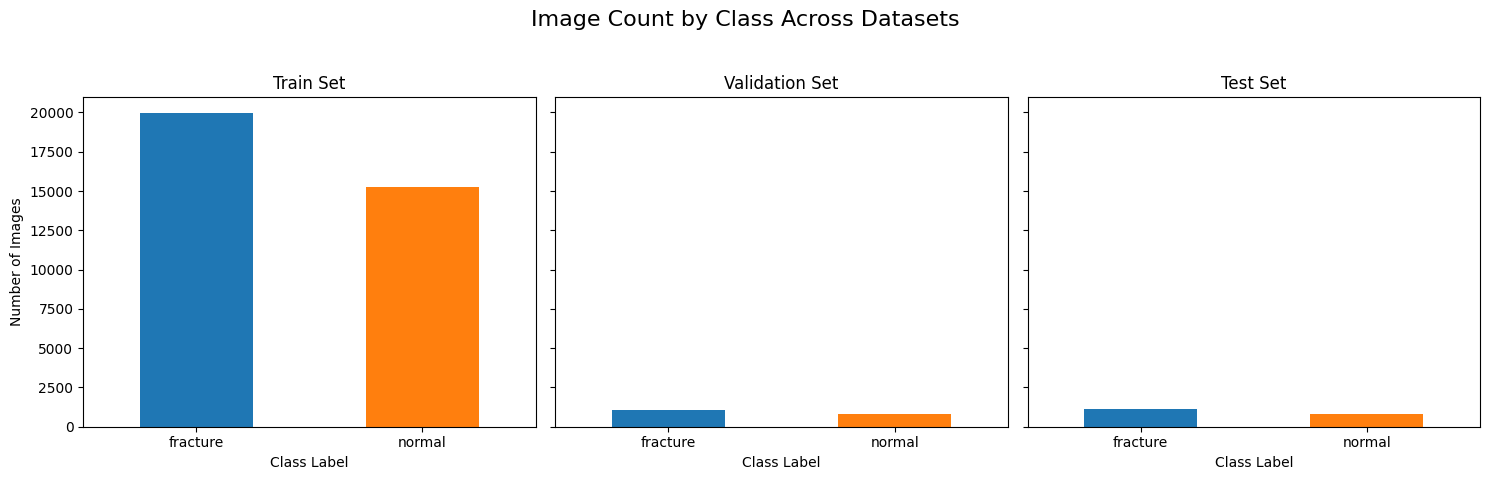

In [ ]:
# =================================================================================
# VISUALIZING THE DATA SPLIT DISTRIBUTION
# =================================================================================

import matplotlib.pyplot as plt
import pandas as pd 

# --- 1. Load the Split Datasets ---
try:
    train_df
    print("Dataframes are already in memory.")
except NameError:
    print("Loading split dataframes from CSV files...")
    train_df = pd.read_csv("train_split.csv")
    val_df = pd.read_csv("val_split.csv")
    test_df = pd.read_csv("test_split.csv")

# --- 2. Define a Function to Print the Counts ---
def summarize_distribution(df, name):
    """Calculates and prints the value counts for the 'label' column."""
    counts = df["label"].value_counts().to_dict()
    print(f"{name} distribution: {counts}")
    return counts

# --- 3. Print the Numerical Summaries ---
print("\n--- Numerical Summary of Splits ---")
train_counts = summarize_distribution(train_df, "Train")
val_counts   = summarize_distribution(val_df, "Validation")
test_counts  = summarize_distribution(test_df, "Test")

# --- 4. Plot the Distributions ---
print("\n--- Visual Summary of Splits ---")
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('Image Count by Class Across Datasets', fontsize=16)

# A list of our dataframes and their titles for easy looping.
datasets_to_plot = [
    (train_df, "Train Set"),
    (val_df, "Validation Set"),
    (test_df, "Test Set")
]

# Loop through each dataframe and create a plot.
for ax, (df_split, title) in zip(axes, datasets_to_plot):
    # Use value_counts() to get the data for the bar chart and plot it.
    df_split["label"].value_counts().plot(
        kind="bar",
        ax=ax,
        color=["#1f77b4", "#ff7f0e"], 
        rot=0 
    )
    ax.set_title(title)
    ax.set_xlabel("Class Label")

axes[0].set_ylabel("Number of Images")


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

Training dataframe is already in memory.


/tmp/ipykernel_201/3108549034.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_counts.index, y=train_counts.values, palette="viridis")


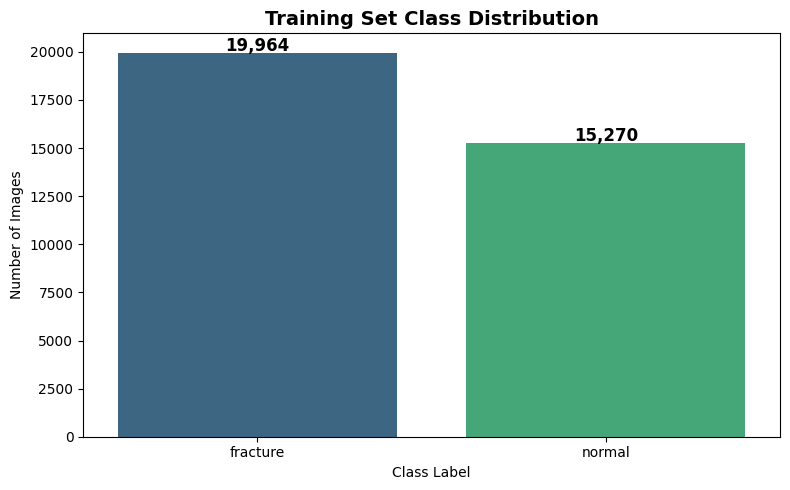


🖼️ Displaying sample images from the training set...


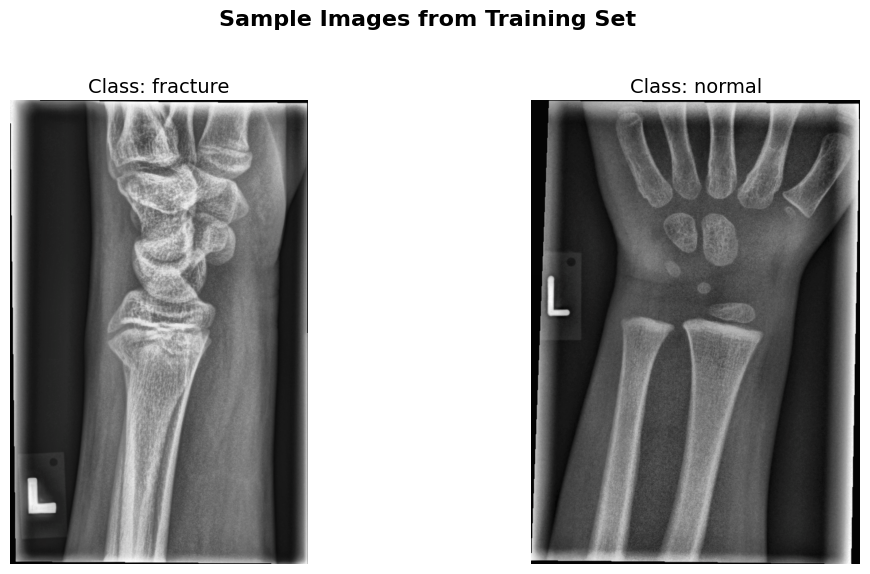

In [ ]:
# =================================================================================
# VISUALIZING THE TRAINING DATASET
# =================================================================================

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pandas as pd 

try:
    train_df
    print("Training dataframe is already in memory.")
except NameError:
    print("Loading training dataframe from 'train_split.csv'...")
    train_df = pd.read_csv("train_split.csv")

plt.style.use('default')
train_counts = train_df['label'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=train_counts.index, y=train_counts.values, palette="viridis")
plt.title('Training Set Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Class Label')
plt.ylabel('Number of Images')
plt.xticks(rotation=0)

for index, value in enumerate(train_counts.values):
    plt.text(index, value + 100, f'{value:,}', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("\n🖼️ Displaying sample images from the training set...")

class_names = train_df['label'].unique().tolist() # This will be ['fracture', 'normal']
fig, axes = plt.subplots(1, len(class_names), figsize=(12, 6))


sample_images = train_df.groupby('label').first()

for i, (class_name, row) in enumerate(sample_images.iterrows()):
    try:
        img = Image.open(row['image_path'])
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Class: {class_name}", fontsize=14)
        axes[i].axis('off')
    except Exception as e:
        axes[i].set_title(f"Error loading {class_name}")
        print(f"Could not load image for {class_name} at path {row['image_path']}: {e}")

plt.suptitle('Sample Images from Training Set', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Validation dataframe is already in memory.


/tmp/ipykernel_201/2321278782.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=val_counts.index, y=val_counts.values, palette="plasma")


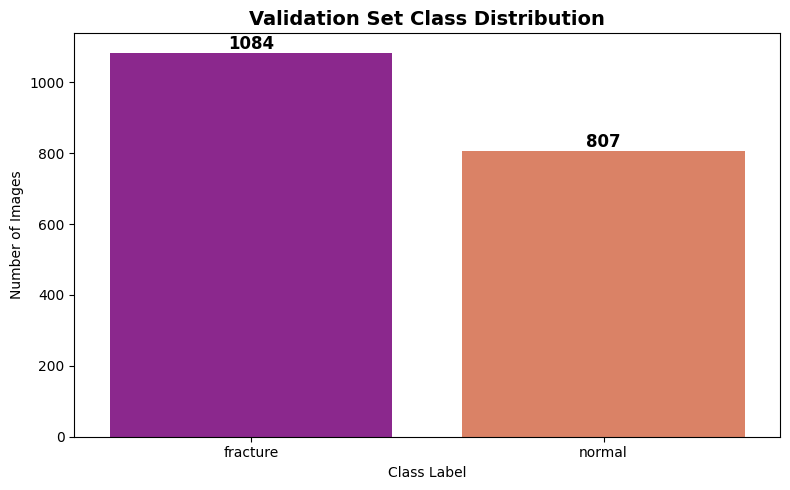


🖼️ Displaying sample images from the validation set...


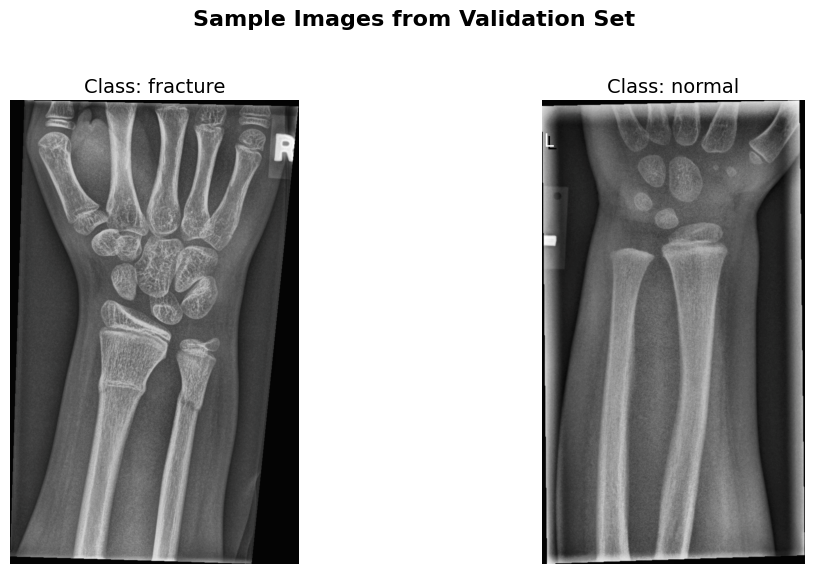

In [ ]:
# =================================================================================
# VISUALIZING THE VALIDATION DATASET
# =================================================================================

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pandas as pd 

try:
    val_df
    print("Validation dataframe is already in memory.")
except NameError:
    print("Loading validation dataframe from 'val_split.csv'...")
    val_df = pd.read_csv("val_split.csv")


val_counts = val_df['label'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=val_counts.index, y=val_counts.values, palette="plasma")
plt.title('Validation Set Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Class Label')
plt.ylabel('Number of Images')
plt.xticks(rotation=0)


for index, value in enumerate(val_counts.values):
    plt.text(index, value + 10, f'{value}', ha='center', fontweight='bold', fontsize=12) # Adjusted offset for better visibility

plt.tight_layout()
plt.show()

print("\n🖼️ Displaying sample images from the validation set...")

class_names = val_df['label'].unique().tolist()

fig, axes = plt.subplots(1, len(class_names), figsize=(12, 6))

sample_images = val_df.groupby('label').first()

for i, (class_name, row) in enumerate(sample_images.iterrows()):
    try:
        img = Image.open(row['image_path'])
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Class: {class_name}", fontsize=14)
        axes[i].axis('off')
    except Exception as e:
        axes[i].set_title(f"Error loading {class_name}")
        print(f"Could not load image for {class_name} at path {row['image_path']}: {e}")

plt.suptitle('Sample Images from Validation Set', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# ==========================================================================
# Convert to Hugging Face Dataset Format
# ==========================================================================
from datasets import Dataset, DatasetDict

print("🔀 Shuffling the training DataFrame...")
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
print("✅ Training DataFrame shuffled.")
print("🚀 Converting pandas DataFrames to Hugging Face Datasets...")

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

# The system prompt sets the context and instructions for the model.
# It clearly defines the model's persona (radiologist AI) and its task.
system_message = """You are a specialized orthopedic radiologist AI.
Analyze the pediatric wrist X-ray for ANY signs of fracture.
OUTPUT: Single word only - 'fracture' or 'normal'."""

data = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset
})

cleanup_memory()

print("\n✅ Conversion complete. Final dataset structure:")
print(data)


🔀 Shuffling the training DataFrame...
✅ Training DataFrame shuffled.
🚀 Converting pandas DataFrames to Hugging Face Datasets...
🧹 Memory Cleanup Complete (0.18s)
   - GPU cache freed: 0.00 GB
   - RAM available: 15.11 GB (9.9%)

✅ Conversion complete. Final dataset structure:
DatasetDict({
    train: Dataset({
        features: ['filestem', 'patient_id', 'image_path', 'fracture_visible', 'ao_classification', 'label', 'fracture_bboxes', 'label_id'],
        num_rows: 35234
    })
    validation: Dataset({
        features: ['filestem', 'patient_id', 'image_path', 'fracture_visible', 'ao_classification', 'label', 'fracture_bboxes', 'label_id'],
        num_rows: 1891
    })
})


In [ ]:
# ==========================================================================
# Load Quantized Model and Processor and LoRA Configuration
# ==========================================================================

import torch
from peft import get_peft_model, LoraConfig
from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig
)

# --- Define Model ID ---
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

# --- Configure 4-bit Quantization (QLoRA) ---
# This configuration enables loading the base model in 4-bit precision,
# drastically reducing its memory footprint.
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# --- Configure LoRA Adapters ---
# This configuration defines the small, trainable layers we will add to the model.
lora_config = LoraConfig(
    r=16,                               # Rank of the update matrices. 
    lora_alpha=32,                      # A scaling factor for the LoRA updates. 
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"], # Apply LoRA to all attention query, key, value, and output projections.
    lora_dropout=0.05,                  # Dropout probability for LoRA layers to prevent overfitting.
    bias="none",                        # Do not train the bias terms.
    task_type="CAUSAL_LM",              # Specify the task type.
    use_rslora=True,                    # For stabilizing LoRA training.
)

# --- Load the Quantized Base Model ---
print(f"🚀 Loading base model: {model_id} with 4-bit quantization...")
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,     # Apply the 4-bit configuration.
    device_map="auto"                   # Automatically distribute the model on available GPUs.
)
print("✅ Base model loaded successfully.")

# --- Apply LoRA Adapters to the Model ---
print("🔧 Applying LoRA adapters...")
model = get_peft_model(model, lora_config)
print("✅ LoRA adapters applied.")

# --- Print Trainable Parameters ---
model.print_trainable_parameters()

# --- Load the Processor with Custom Resizing ---
print("\n🔄 Loading processor with custom image size constraints...")

# set the max to the model's native resolution (448x448) for optimal performance.
target_max_dim = 672
target_min_dim = 448 # A sensible lower bound to handle small images like 64x64.

# The processor expects the total number of pixels (width * height).
max_pixels = target_max_dim * target_max_dim
min_pixels = target_min_dim * target_min_dim

# Load the processor, overriding its default resizing behavior for our specific dataset.
processor = AutoProcessor.from_pretrained(
    model_id,
    min_pixels=min_pixels,
    max_pixels=max_pixels
)
print(f"✅ Processor loaded. Images will be resized to fit within a resolution of ~{target_min_dim}px to {target_max_dim}px.")


2025-11-10 14:23:04.693075: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-10 14:23:04.746420: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-10 14:23:04.746463: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-10 14:23:04.747931: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-10 14:23:04.757048: I tensorflow/core/platform/cpu_feature_guar

🚀 Loading base model: Qwen/Qwen2.5-VL-3B-Instruct with 4-bit quantization...


Loading checkpoint shards: 100%|██████████| 2/2 [00:10<00:00,  5.09s/it]


✅ Base model loaded successfully.
🔧 Applying LoRA adapters...
✅ LoRA adapters applied.
trainable params: 7,372,800 || all params: 3,761,995,776 || trainable%: 0.1960

🔄 Loading processor with custom image size constraints...


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


✅ Processor loaded. Images will be resized to fit within a resolution of ~448px to 672px.


In [ ]:
# ==========================================================================
# Define the VLMDataCollator Class
# ==========================================================================

import torch
import torchvision.transforms as T
from qwen_vl_utils import process_vision_info
from PIL import Image

class VLMDataCollator:
    def __init__(self, processor, system_message, augment=False):
        self.processor = processor
        self.system_message = system_message
        self.augment = augment

        # Define a conservative augmentation pipeline suitable for medical images
        self.augmentation_transforms = T.Compose([
            #T.RandomHorizontalFlip(p=0.5),
            T.RandomAffine(degrees=5, translate=(0.03, 0.03), scale=(0.97, 1.03), fill=0),
            T.ColorJitter(brightness=0.1, contrast=0.1),
            T.GaussianBlur(kernel_size=3, sigma=(0.1, 0.3)),
        ])

    def __call__(self, examples):
        processed_conversations = []
        for example in examples:
            try:
                image = Image.open(example['image_path']).convert("RGB")
            except FileNotFoundError:
                print(f"Warning: Image not found at {example['imagePath']}. Skipping.")
                continue
            except Exception as e:
                print(f"Warning: Error loading image {example['imagePath']}: {e}. Skipping.")
                continue

            conversation = [
                {"role": "system", "content": [{"type": "text", "text": self.system_message}]},
                {"role": "user", "content": [{"type": "image", "image": image}, {"type": "text", "text": "Does this wrist X-ray show a fracture?"}]},
                {"role": "assistant", "content": [{"type": "text", "text": example['label']}]},
            ]
            processed_conversations.append(conversation)

        if not processed_conversations:
            print("Warning: Empty batch after processing.")
            return {}
       
        # Apply chat template and process images
        texts = [
            processor.apply_chat_template(conv, tokenize=False, add_generation_prompt=False)
            for conv in processed_conversations
        ]
        image_inputs, _ = process_vision_info(processed_conversations)

        
        batch = processor(
            text=texts,
            images=image_inputs,
            padding=True,
            truncation=False,
            max_length=None,
            return_tensors="pt"
        )
        # Create labels with proper masking
        labels = batch["input_ids"].clone()

        for i, conv in enumerate(processed_conversations):
            full_ids = batch["input_ids"][i]

            # Find the assistant response marker
            assistant_start_marker = processor.tokenizer.encode(
                "<|im_start|>assistant\n", 
                add_special_tokens=False
            )
            marker_length = len(assistant_start_marker)
            marker_tensor = torch.tensor(assistant_start_marker, device=full_ids.device)

            # Search for the marker and mask everything before it
            found = False
            for j in range(len(full_ids) - marker_length + 1):
                if torch.equal(full_ids[j:j+marker_length], marker_tensor):
                    labels[i, :j+marker_length] = -100
                    found = True
                    break

            if not found:
                print(f"Warning: Assistant marker not found in sample {i}")
                labels[i, :] = -100

        # Mask padding tokens
        labels[labels == processor.tokenizer.pad_token_id] = -100
        batch["labels"] = labels

        return batch
        
print("✅ VLMDataCollator class defined.") 

✅ VLMDataCollator class defined.


In [ ]:
# =================================================================================
# Define the Custom SFTTrainer
# =================================================================================
from trl import SFTTrainer

class SFTTrainerWithDualCollators(SFTTrainer):
    def __init__(self, *args, train_collator=None, eval_collator=None, **kwargs):
        self.train_collator_instance = train_collator
        self.eval_collator_instance = eval_collator
        # Initialize the base trainer with the training collator by default
        super().__init__(*args, data_collator=train_collator, **kwargs)

    def get_train_dataloader(self):
        # This method is called by .train()
        self.data_collator = self.train_collator_instance
        return super().get_train_dataloader()

    def get_eval_dataloader(self, eval_dataset=None):
        # This method is called by .evaluate()
        self.data_collator = self.eval_collator_instance
        return super().get_eval_dataloader(eval_dataset)


In [ ]:
# =================================================================================
# Configure Training Arguments
# =================================================================================

import os
from trl import SFTConfig

os.environ["WANDB_DISABLED"] = "true"
os.environ["TOKENIZERS_PARALLELISM"] = "false"


training_args = SFTConfig(
    output_dir="training folder/Pediatric_Fracture_Dataset",
    save_strategy="steps",      
    save_steps= 200,
    save_total_limit=5,        

    # --- Core Training Parameters ---
    num_train_epochs=2,         
    per_device_train_batch_size=4, 
    per_device_eval_batch_size=4,  
    gradient_accumulation_steps=4, 

    # --- Memory & Performance Optimization ---
    gradient_checkpointing=True,   
    gradient_checkpointing_kwargs={"use_reentrant": False}, 
    bf16=True,                     
    optim="adamw_torch_fused",     

    # --- Learning Rate & Scheduler ---
    learning_rate=5e-5,         
    lr_scheduler_type="cosine", 
    warmup_ratio=0.05,           
    weight_decay=0.01,          

    # --- Evaluation & Logging ---
    eval_strategy="steps",      
    eval_steps=200,
    logging_strategy="steps",
    logging_steps=25,           
    logging_first_step=True,    
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss", 
    greater_is_better=False,    

    # --- Dataset & DataLoader ---
    dataloader_num_workers=4,   
    dataloader_pin_memory=True, 
    remove_unused_columns=False,

    # --- SFTConfig Specific Parameters ---
    assistant_only_loss=False,  

    # Specify the EOS token directly in the config.
    eos_token="<|im_end|>",
    dataset_kwargs={
        "skip_prepare_dataset": True,
    },

)

In [ ]:
# =================================================================================
# Initialize and Run the Trainer
# =================================================================================
from trl import SFTTrainer 

# --- Instantiate the two collators ---
print("🚀 Instantiating data collators...")
train_collate_fn = VLMDataCollator(processor, system_message, augment=False)
eval_collate_fn = VLMDataCollator(processor, system_message, augment=False)
print("   - Training collator (WITHout augmentation) is ready.")
print("   - Evaluation collator (WITHOUT augmentation) is ready.")


# --- Initialize the custom trainer ---
print("\n🚀 Initializing SFTTrainerWithDualCollators...")
trainer = SFTTrainerWithDualCollators(
    model=model,
    args=training_args,
    train_dataset=data["train"],
    eval_dataset=data["validation"],
    train_collator=train_collate_fn, 
    eval_collator=eval_collate_fn,   
)
print("✅ Custom trainer initialized successfully!")

# --- Logic to Resume Training from a Checkpoint ---
last_checkpoint = None
output_dir = training_args.output_dir
if os.path.isdir(output_dir):
    # Find all directories that start with "checkpoint-"
    checkpoints = [d for d in os.listdir(output_dir) if d.startswith("checkpoint-")]
    if checkpoints:
        # Find the checkpoint with the highest step number (the most recent one).
        last_checkpoint = max(checkpoints, key=lambda x: int(x.split('-')[-1]))
        last_checkpoint = os.path.join(output_dir, last_checkpoint)
        print(f"🔄 Resuming training from checkpoint: {last_checkpoint}")
    else:
        print("🚀 No checkpoints found, starting a fresh training run.")

# --- Start the Training Process ---
print("\n🎯 Starting model training...")
try:
    # Begin the training loop. If `last_checkpoint` is not None, it will resume from there.
    trainer.train(resume_from_checkpoint=last_checkpoint)

    print("\n🎉 Training completed successfully!")

    # Save the final, best-performing model and the processor to a "final_model" directory.
    final_model_path = os.path.join(training_args.output_dir, "final_model")
    print(f"💾 Saving final model to: {final_model_path}")
    trainer.save_model(final_model_path)
    processor.save_pretrained(final_model_path)
    print("✅ Final model and processor saved.")

except Exception as e:
    print(f"❌ Training failed with an error: {e}")
    # If training is interrupted, save an emergency checkpoint to avoid losing all progress.
    emergency_path = os.path.join(training_args.output_dir, "emergency_checkpoint")
    trainer.save_model(emergency_path)
    print(f"🚨 Emergency checkpoint saved to: {emergency_path}")


🚀 Instantiating data collators...
   - Training collator (WITHout augmentation) is ready.
   - Evaluation collator (WITHOUT augmentation) is ready.

🚀 Initializing SFTTrainerWithDualCollators...
✅ Initialized MemoryOptimizedCallback: will clean memory every 100 steps.

--- Memory Cleanup triggered by: on_init_end ---
  Before cleanup: GPU: 2.28GB, CPU: 4.08GB


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


  After cleanup: GPU: 2.28GB, CPU: 4.08GB
-------------------------------
✅ Custom trainer initialized successfully!
🚀 No checkpoints found, starting a fresh training run.

🎯 Starting model training...

--- Memory Cleanup triggered by: on_train_begin ---
  Before cleanup: GPU: 2.28GB, CPU: 4.08GB
  After cleanup: GPU: 2.28GB, CPU: 4.08GB
----------------------------------

--- Epoch 0/2 Begins ---

--- Memory Cleanup triggered by: on_epoch_begin (Epoch 0) ---
  Before cleanup: GPU: 2.28GB, CPU: 4.08GB
  After cleanup: GPU: 2.28GB, CPU: 4.07GB
--------------------------------------------


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
200,0.147300,0.138189,2.634691,1884967.000000,0.930233
400,0.112300,0.145904,2.612797,3774248.000000,0.930655
600,0.105200,0.095111,2.646399,5658772.000000,0.958703
800,0.084700,0.108850,2.710557,7535524.000000,0.951409
1000,0.085400,0.074074,2.736616,9419977.000000,0.968710
1200,0.069700,0.076789,2.717040,11300127.000000,0.967336
1400,0.074200,0.072844,2.643618,13177660.000000,0.971071
1600,0.059200,0.066339,2.722446,15054108.000000,0.972727
1800,0.065900,0.067346,2.684250,16934046.000000,0.974912
2000,0.069900,0.066265,2.691596,18816174.000000,0.973749



--- Memory Cleanup triggered by: on_evaluate (Step 200) ---
  Before cleanup: GPU: 2.50GB, CPU: 6.15GB
  After cleanup: GPU: 2.50GB, CPU: 6.13GB
------------------------------------------


...


--- Memory Cleanup triggered by: on_save (Step 4200) ---
  Before cleanup: GPU: 2.51GB, CPU: 5.92GB
  After cleanup: GPU: 2.51GB, CPU: 5.92GB
---------------------------------------

--- Memory Cleanup triggered by: on_evaluate (Step 4400) ---
  Before cleanup: GPU: 2.50GB, CPU: 9.73GB
  After cleanup: GPU: 2.50GB, CPU: 9.72GB
-------------------------------------------


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).



--- Memory Cleanup triggered by: on_save (Step 4400) ---
  Before cleanup: GPU: 2.50GB, CPU: 9.71GB
  After cleanup: GPU: 2.50GB, CPU: 9.71GB
---------------------------------------


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).



--- Memory Cleanup triggered by: on_save (Step 4406) ---
  Before cleanup: GPU: 2.37GB, CPU: 8.13GB
  After cleanup: GPU: 2.37GB, CPU: 8.11GB
---------------------------------------

--- Training Ended (Total Duration: 76182.41 seconds) ---

--- Memory Cleanup triggered by: on_train_end ---
  Before cleanup: GPU: 2.37GB, CPU: 8.11GB
  After cleanup: GPU: 2.37GB, CPU: 8.11GB
--------------------------------

🎉 Training completed successfully!
💾 Saving final model to: training folder/Pediatric_Fracture_Dataset
✅ Final model and processor saved.


In [ ]:
# ===================================================================
# TESTING
# -------
# DEFINE THE INFERENCE FUNCTION 
# ===================================================================
model.eval()

DEVICE = next(model.parameters()).device
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
def run_inference(image_path: str):
    """Takes an image path, prepares the prompt, and gets a prediction."""
    try:
        image = Image.open(image_path).convert("RGB")
    except FileNotFoundError:
        return "ERROR: Image not found"

    conversation = [
        {"role": "system", "content": [{"type": "text", "text": system_message}]},
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": "Does this wrist X-ray show a fracture?"},
            ],
        },
    ]

    text = processor.apply_chat_template(conversation, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt").to(DEVICE)

    stop_token_id = 151645 # <|im_end|>

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=10, # Only need a few tokens for "fracture" or "normal"
            do_sample=False,
            eos_token_id=stop_token_id,
            pad_token_id=processor.tokenizer.pad_token_id
        )

    generated_tokens = output_ids[0, len(inputs['input_ids'][0]):]
    response = processor.decode(generated_tokens, skip_special_tokens=True).strip()

    return response

print("✅ ROBUST Inference function is ready.")


✅ ROBUST Inference function is ready.



🧪 Starting evaluation run on 1927 test samples...


100%|██████████| 1927/1927 [22:54<00:00,  1.40it/s]



✅ Evaluation loop complete.

📊 FINAL PERFORMANCE METRICS ON TEST SET

Classification Report:
              precision    recall  f1-score   support

    fracture       0.95      0.88      0.91      1114
      normal       0.85      0.94      0.89       813

    accuracy                           0.90      1927
   macro avg       0.90      0.91      0.90      1927
weighted avg       0.91      0.90      0.90      1927


Confusion Matrix:
[[978 136]
 [ 51 762]]


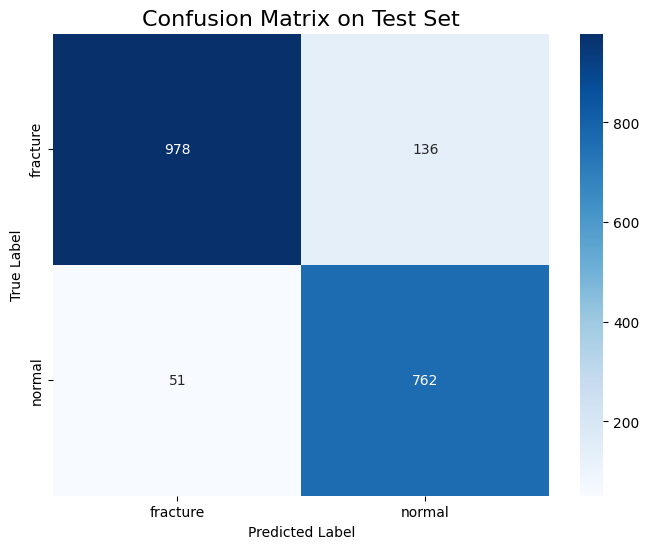

In [ ]:
# ===================================================================
# RUN EVALUATION LOOP AND CALCULATE METRICS 
# ===================================================================
print(f"\n🧪 Starting evaluation run on {len(test_df)} test samples...")

predictions = []
ground_truths = []

for index, row in tqdm(test_df.iterrows(), total=len(test_df)):
    image_path = row['image_path']
    true_label = row['label']

    predicted_text = run_inference(image_path)

    # Use a robust check to see if the prediction is correct
    if true_label.lower() in predicted_text.lower():
        final_prediction = true_label
    else:
        # If no match, assign the opposite label for our binary case.
        other_label = "normal" if true_label == "fracture" else "fracture"
        # We can be more specific here. If the model says anything other than the true label,
        # we assume it's trying to say the other one.
        if other_label in predicted_text.lower():
             final_prediction = other_label
        else:
             final_prediction = "unknown" # Or handle unexpected outputs

    predictions.append(final_prediction)
    ground_truths.append(true_label)

print("\n✅ Evaluation loop complete.")

# --- Calculate and Display Metrics ---
print("\n" + "="*50)
print("📊 FINAL PERFORMANCE METRICS ON TEST SET")
print("="*50)

# Define the labels for the report
class_labels = ["fracture", "normal"]

report = classification_report(ground_truths, predictions, target_names=class_labels, zero_division=0)
print("\nClassification Report:")
print(report)

# Generate and plot the confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(ground_truths, predictions, labels=class_labels)
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix on Test Set', fontsize=16)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()